<a href="https://colab.research.google.com/github/Shraddha063/nde-signal-ultrasonic-defect-classification/blob/main/notebooks/nde_defect_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic NDE dataset...
Applying Butterworth Bandpass Filter & Wavelet Denoising...
Training 1D CNN on device: cuda...
Epoch [5/15], Loss: 0.0127
Epoch [10/15], Loss: 0.0031
Epoch [15/15], Loss: 0.0018

--- CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

  Normal Signal       1.00      1.00      1.00       125
Defect Detected       1.00      1.00      1.00       115

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



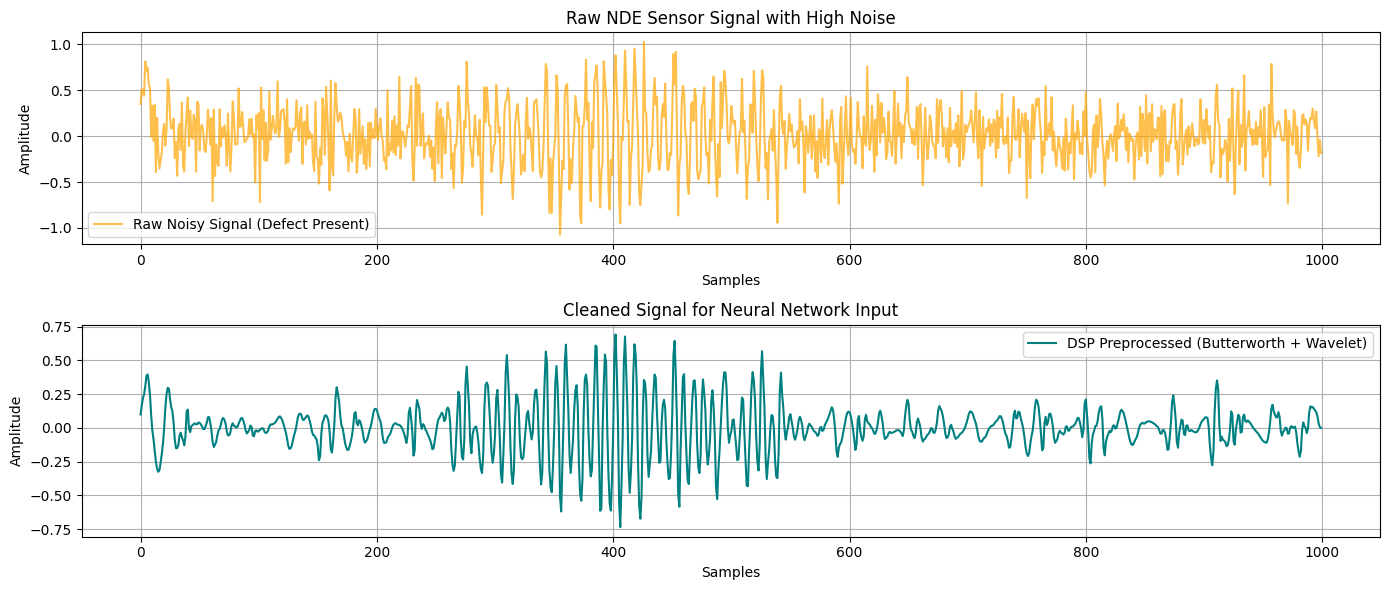

In [1]:
import numpy as np
import scipy.signal as signal
import pywt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Fix seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. SYNTHETIC NDE SIGNAL GENERATION
# ==========================================
def generate_nde_signal(has_defect=False, num_samples=1000, fs=10000):
    t = np.linspace(0, num_samples/fs, num_samples)

    # Base structural ultrasonic signal (attenuating sine wave burst)
    base_signal = np.sin(2 * np.pi * 500 * t) * np.exp(-1000 * t)

    # Add defect signature (reflection echo) if defect exists
    defect = np.zeros_like(t)
    if has_defect:
        defect_location = 0.04 # second reflection peak
        defect = 0.6 * np.sin(2 * np.pi * 1200 * (t - defect_location)) * np.exp(-5000 * (t - defect_location)**2)

    # Add heavy industrial background noise (Gaussian)
    noise = np.random.normal(0, 0.25, size=num_samples)

    raw_signal = base_signal + defect + noise
    return raw_signal

print("Generating synthetic NDE dataset...")
X_raw = []
y_labels = []

# Generate 1200 samples (600 Normal, 600 Defective)
for _ in range(600):
    X_raw.append(generate_nde_signal(has_defect=False))
    y_labels.append(0) # Normal

    X_raw.append(generate_nde_signal(has_defect=True))
    y_labels.append(1) # Defect

X_raw = np.array(X_raw)
y_labels = np.array(y_labels)

# ==========================================
# 2. DSP PREPROCESSING (Filtering & Wavelets)
# ==========================================
def preprocess_dsp(signals, fs=10000):
    processed = []
    # Design Butterworth Bandpass Filter (300 Hz to 2000 Hz)
    b, a = signal.butter(4, [300, 2000], btype='bandpass', fs=fs)

    for sig in signals:
        # Step 1: Bandpass Filtering
        filtered = signal.filtfilt(b, a, sig)

        # Step 2: Wavelet Threshold Denoising (db4 wavelet)
        coeffs = pywt.wavedec(filtered, 'db4', level=3)
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        uthresh = sigma * np.sqrt(2 * np.log(len(filtered)))
        coeffs[1:] = [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]
        denoised = pywt.waverec(coeffs, 'db4')

        # Trim/pad to maintain exact sample length
        processed.append(denoised[:len(sig)])

    return np.array(processed)

print("Applying Butterworth Bandpass Filter & Wavelet Denoising...")
X_clean = preprocess_dsp(X_raw)

# ==========================================
# 3. PYTORCH 1D CNN ARCHITECTURE
# ==========================================
class NDESignalClassifier1D(nn.Module):
    def __init__(self):
        super(NDESignalClassifier1D, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_labels, test_size=0.2, random_state=42)

# Convert to PyTorch Tensors (N, C, L format for 1D CNN)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# ==========================================
# 4. MODEL TRAINING & EVALUATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NDESignalClassifier1D().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Training 1D CNN on device: {device}...")
model.train()
epochs = 15
for epoch in range(epochs):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    test_inputs = X_test_t.to(device)
    outputs = model(test_inputs)
    _, preds = torch.max(outputs, 1)
    preds = preds.cpu().numpy()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, preds, target_names=['Normal Signal', 'Defect Detected']))

# ==========================================
# 5. VISUALIZATION OF RESULTS
# ==========================================
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(X_raw[1], label='Raw Noisy Signal (Defect Present)', color='orange', alpha=0.7)
plt.title('Raw NDE Sensor Signal with High Noise')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(X_clean[1], label='DSP Preprocessed (Butterworth + Wavelet)', color='teal')
plt.title('Cleaned Signal for Neural Network Input')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()